# SPI_A capture decoder: source vs. transport

Decodes a raw digital logic-analyzer capture of the shared **SPI_A** bus (NRF <-> ADS1298 A/B, NRF <-> ESP32) and reconstructs the 16 ADS channels (8 from A + 8 from B) **two different ways**:

1. **Directly** from the `ADS_A-CS` / `ADS_B-CS` transactions' MISO bytes -- the ADS1298's own raw 27-byte read response (3 status bytes + 8 channels x 3 bytes, big-endian 2's complement).
2. **From the ESP-CS transactions' MOSI bytes** -- the assembled 211-byte EXG packet the NRF sends onward to the ESP, using the same channel offsets as `interface_biogapultra_eeg.py`'s `decodeFn()`.

Comparing (1) vs (2) for the same channel answers the question *"is a data-quality problem introduced at the ADS1298 itself, or during the NRF -> ESP hand-off?"* -- if (1) is already bad, the transport is innocent; if (1) is clean but (2) isn't, look at `ads_spi_data.c` / SPI_A bus contention instead.

**Protocol assumptions** (must match `spi/spi_a.c`'s config): SPI Mode 1 (`NRF_SPIM_MODE_1` -- CPOL=0, CPHA=1) means each bit is sampled on the CLK **falling** edge; bits are packed **MSB-first** (`NRF_SPIM_BIT_ORDER_MSB_FIRST`).

In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
print(Path.cwd())

c:\Users\giusy\BIOGAP\BioGAP\Firmware\utils


## 1. Configuration

`CSV_PATH` is a Saleae-style **sparse, event-driven** digital export: one row per transition (not a fixed sample rate), with columns `Time [s], SPI_A_MOSI, SPI_A_MISO, SPI_A_CLK, gpio_ads1298_a_spi_cs, gpio_ads1298_b_spi_cs, gpio_nrf_esp_cs, ADSA_DR`.

The ADS1298 channel scaling below matches `interface_biogapultra_eeg.py` exactly, so a channel decoded here should be numerically identical to what BioGUI would show for the same bytes.

In [19]:
CSV_PATH = Path.cwd()/r"digital_corrupted.csv"

# --- ADS1298 channel scaling (matches interface_biogapultra_eeg.py) ---
_VREF = 2.5          # V
_GAIN = 6             # ADS1298 register 0x00 = gain 6
_NBIT = 24
_SCALE = _VREF / (_GAIN * (2 ** (_NBIT - 1) - 1)) * 1e6  # ADC code -> uV
_N_CH = 8             # channels per ADS chip
_BYTES_CH = 3         # 24-bit
_ADS_BYTES = _N_CH * _BYTES_CH  # 24

# EXG packet layout (211 bytes): header@0, counter@1:3, timestamp@3:7,
# then 4 sample blocks of 50 bytes each starting at byte 7 (ADS_A 24B + ADS_B 24B + 2 extra)
_N_SAMPLES = 4
_SAMPLE_OFFSETS = [7 + i * 50 for i in range(_N_SAMPLES)]
_EXG_HEADER = 0x55
_EXG_TAILER = 0xAA

## 2. Load the capture

This is the slow step for a multi-million-row file (tens of seconds) -- everything after this is fast, vectorized numpy work.

The digital analyzer is currently configured to have:

D1 --> SPI_A_MOSI

D2--> SPI_A_MISO

D3 --> SPI_A_CLK

D4 --> gpio_ads1298_a_spi_cs (0.11)[spi_a_cs]

D5 --> gpio_ads1298_b_spi_cs (1.09)

D6 --> gpio_nrf_esp_cs (0.14)

In [20]:
def load_capture(path):
    t0 = time.time()
    data = np.genfromtxt(path, delimiter=",", skip_header=1, dtype=np.float64)
    print(f"Loaded {data.shape[0]} rows in {time.time()-t0:.1f}s")
    return {
        "t": data[:, 0],
        "mosi": data[:, 1].astype(np.uint8),
        "miso": data[:, 2].astype(np.uint8),
        "clk": data[:, 3].astype(np.uint8),
        "cs_a": data[:, 4].astype(np.uint8),
        "cs_b": data[:, 5].astype(np.uint8),
        "cs_esp": data[:, 6].astype(np.uint8),
    }

cap = load_capture(CSV_PATH)
print(f"Capture duration: {cap['t'][-1] - cap['t'][0]:.2f} s")

Loaded 13717208 rows in 83.7s
Capture duration: 15.16 s


## 3. Extract transactions

A *transaction* is one CS-low window (falling edge to the next rising edge) on a given chip-select line. Within that window we find every CLK falling edge and sample MOSI/MISO at that instant -- that's the SPI Mode 1 sampling point -- then pack every 8 bits MSB-first into a byte.

Because the CSV is sparse (only transition rows are recorded), the row at a given falling edge already reflects the state of every other channel at that exact instant, so no interpolation is needed.

In [21]:
def find_transactions(cs):
    """Return list of (start_idx, end_idx) index pairs where cs is low (active)."""
    falling = np.where((cs[:-1] == 1) & (cs[1:] == 0))[0] + 1
    rising = np.where((cs[:-1] == 0) & (cs[1:] == 1))[0] + 1
    pairs = []
    ri = 0
    for f in falling:
        while ri < len(rising) and rising[ri] <= f:
            ri += 1
        if ri < len(rising):
            pairs.append((f, rising[ri]))
    return pairs


def decode_bytes(clk, line, start, end):
    """Sample `line` at every CLK falling edge strictly within [start, end),
    pack bits MSB-first into bytes. Returns (bytes, n_bytes)."""
    window_clk = clk[start:end]
    falling = np.where((window_clk[:-1] == 1) & (window_clk[1:] == 0))[0] + 1
    bits = line[start:end][falling]
    n_bytes = len(bits) // 8
    bits = bits[: n_bytes * 8].reshape(n_bytes, 8)
    weights = (1 << np.arange(7, -1, -1)).astype(np.uint16)
    byte_vals = (bits.astype(np.uint16) * weights).sum(axis=1).astype(np.uint8)
    return byte_vals.tobytes(), n_bytes


def decode_all_transactions(cap, cs, label):
    pairs = find_transactions(cs)
    out = []
    for start, end in pairs:
        mosi_bytes, n1 = decode_bytes(cap["clk"], cap["mosi"], start, end)
        miso_bytes, n2 = decode_bytes(cap["clk"], cap["miso"], start, end)
        assert n1 == n2
        out.append({"t": cap["t"][start], "mosi": mosi_bytes, "miso": miso_bytes, "n": n1})
    sizes = np.array([o["n"] for o in out])
    print(f"{label}: {len(out)} transactions, size histogram: "
          f"{dict(zip(*np.unique(sizes, return_counts=True)))}")
    return out

In [22]:
ads_a_tx = decode_all_transactions(cap, cap["cs_a"], "ADS_A")
ads_b_tx = decode_all_transactions(cap, cap["cs_b"], "ADS_B")
esp_tx = decode_all_transactions(cap, cap["cs_esp"], "ESP")

ADS_A: 6542 transactions, size histogram: {3: 1, 27: 6534, 40: 7}
ADS_B: 6542 transactions, size histogram: {3: 1, 27: 6534, 40: 7}
ESP: 5241 transactions, size histogram: {0: 3293, 4: 315, 211: 1633}


**Reading the size histogram:**
- ADS_A / ADS_B: `27` bytes is a normal `ads1298_read_samples()` read (3 status + 24 data bytes). `3` bytes is the one-time `ads_check_id()` RREG read. `40` bytes is a known, separate bug -- `ads1298_write_spi()` (`ads_spi_comm.c`) ignores its own `size` parameter and always sends `sizeof(pr_word)`/`sizeof(ads_rx_buf)` (10/40 bytes) regardless of the intended command size; harmless to this analysis (those transactions are commands, not data reads) but worth fixing separately.
- ESP: `211` bytes is a real EXG data packet, `4` bytes is the DRDY-triggered dummy control transceive (`process_esp_data()`), `0` bytes is a CS glitch/very short pulse with no clock activity.

## 4. Unpack channel data

Each 24-bit sample is big-endian, 2's-complement, scaled to microvolts. This is the exact same math as `_unpack_ads_block()` in `interface_biogapultra_eeg.py`, so results here should match BioGUI's own decode of the same bytes.

In [23]:
def unpack_ads_block(data, offset):
    """24-byte block -> 8 channel float32 uV array (big-endian, 2's complement)."""
    out = np.empty(_N_CH, dtype=np.float32)
    for ch in range(_N_CH):
        b = offset + ch * _BYTES_CH
        raw = (data[b] << 16) | (data[b + 1] << 8) | data[b + 2]
        if raw >= 0x800000:
            raw -= 0x1000000
        out[ch] = raw * _SCALE
    return out


def decode_ads_direct(transactions):
    """ADS1298 raw read response (MISO): [3 status][24 data] = 27 bytes."""
    rows = [unpack_ads_block(tr["miso"], 3) for tr in transactions if tr["n"] == 27]
    return np.array(rows) if rows else np.empty((0, _N_CH))


def decode_from_esp_packets(transactions):
    """EXG packet (MOSI, 211 bytes) -> (n_packets*4, 8) for A and B, plus the packet counters."""
    rows_a, rows_b, counters = [], [], []
    for tr in transactions:
        d = tr["mosi"]
        if tr["n"] != 211 or d[0] != _EXG_HEADER or d[210] != _EXG_TAILER:
            continue
        counter = d[1] | (d[2] << 8)
        for base in _SAMPLE_OFFSETS:
            rows_a.append(unpack_ads_block(d, base))
            rows_b.append(unpack_ads_block(d, base + _ADS_BYTES))
        counters.append(counter)
    return np.array(rows_a), np.array(rows_b), np.array(counters)

In [24]:
ads_a_direct = decode_ads_direct(ads_a_tx)
ads_b_direct = decode_ads_direct(ads_b_tx)
esp_a, esp_b, esp_counters = decode_from_esp_packets(esp_tx)

print(f"ADS_A direct: {ads_a_direct.shape}, ADS_B direct: {ads_b_direct.shape}")
print(f"From ESP packets -- A: {esp_a.shape}, B: {esp_b.shape}, valid packets: {len(esp_counters)}")

ADS_A direct: (6534, 8), ADS_B direct: (6534, 8)
From ESP packets -- A: (6532, 8), B: (6532, 8), valid packets: 1633


### Sanity check: does the decoder itself work?

The EXG packet's own counter should increment by exactly 1 every packet. If it doesn't, either real packets were dropped on the wire (a hardware/firmware issue) or the decoder mis-parsed a transaction (a bug in this notebook) -- worth ruling out the second before trusting any conclusion drawn from the plots below.

In [25]:
if len(esp_counters):
    gaps = np.where(np.diff(esp_counters.astype(np.int32)) != 1)[0]
    print(f"ESP packet counter gaps: {len(gaps)} (0 = decoder + transport both clean)")

ESP packet counter gaps: 0 (0 = decoder + transport both clean)


## 5. Plot and compare

Same layout convention as `bio_reader.ipynb`: one subplot per channel, shared x-axis, stacked top to bottom.

In [26]:
def plot_block(data, title, ylim=None):
    n_ch = data.shape[1] if data.size else _N_CH
    fig, axs = plt.subplots(n_ch, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(title)
    for i in range(n_ch):
        axs[i].plot(data[:, i], linewidth=0.7, label=f"ch{i+1}")
        if ylim:
            axs[i].set_ylim(ylim)
        axs[i].legend(loc="upper right", fontsize=7)
    axs[-1].set_xlabel("sample #")
    fig.tight_layout()
    plt.show()

### ADS_A, direct from its own SPI transaction (reference / sanity check)

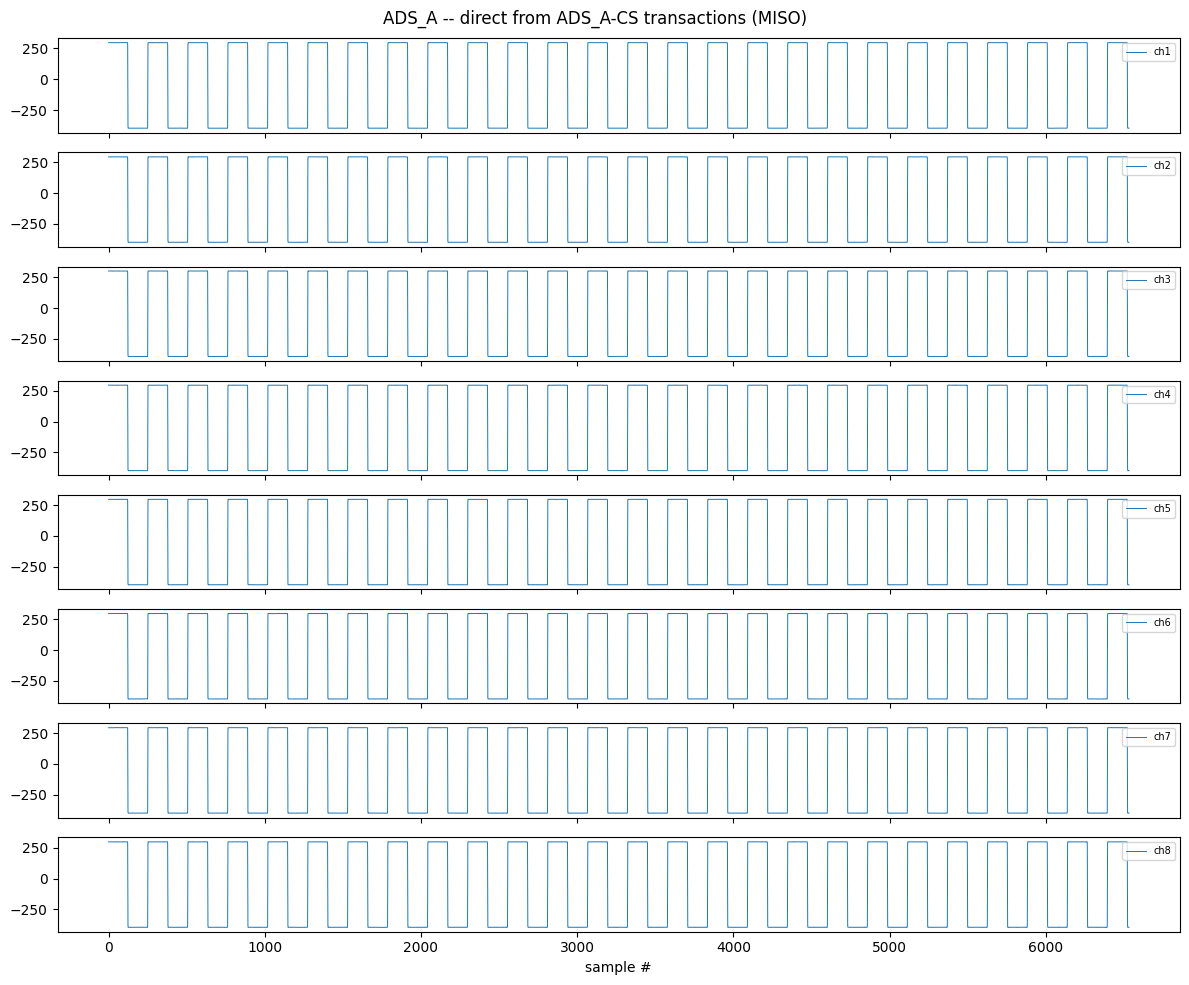

In [27]:
plot_block(ads_a_direct, "ADS_A -- direct from ADS_A-CS transactions (MISO)")

### ADS_B, direct from its own SPI transaction -- the actual question

If this already looks wrong, the problem is at the ADS1298_B chip / its own SPI read, *before* the NRF ever touches the ESP or WiFi -- nothing downstream can be the cause.

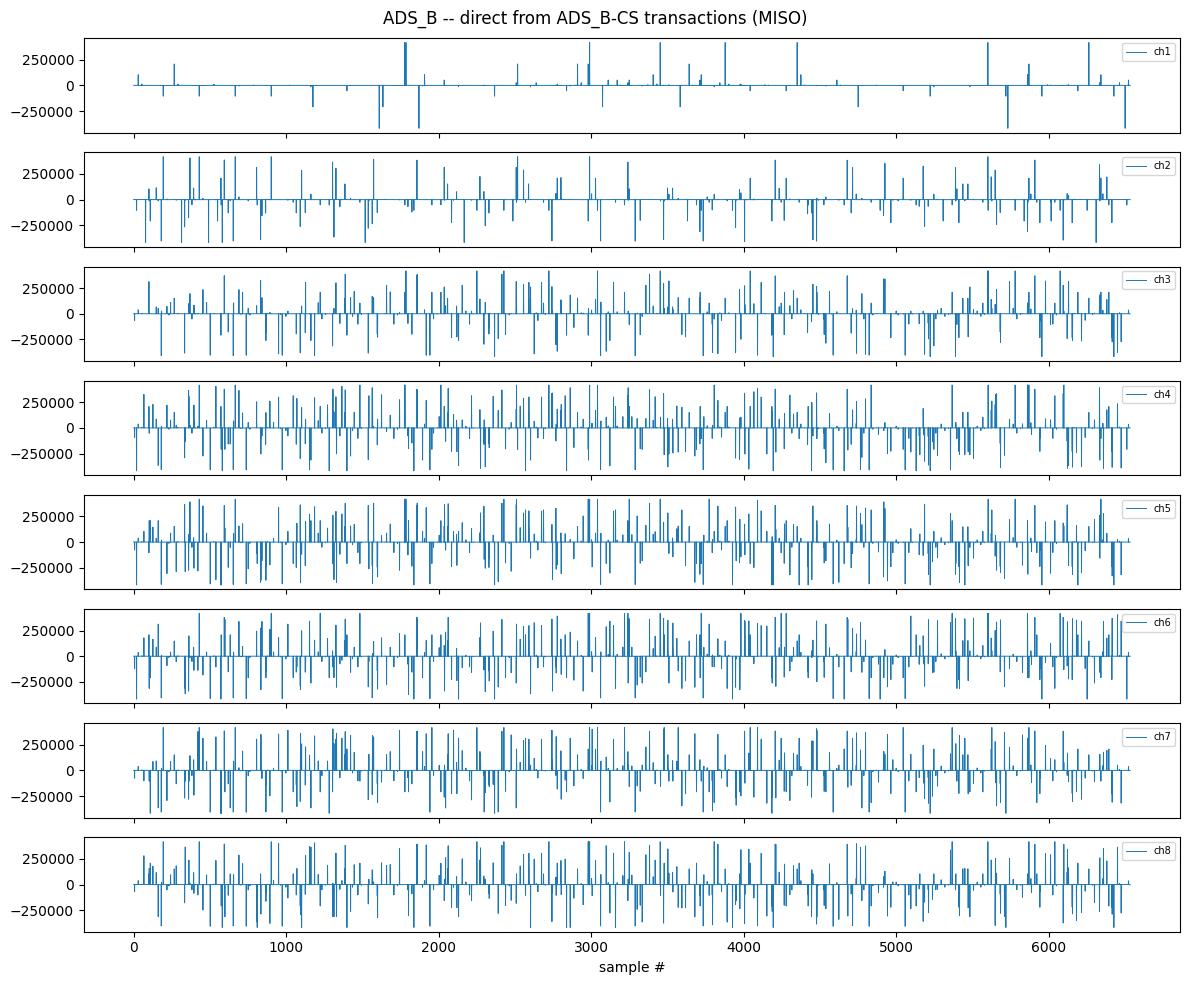

In [28]:
plot_block(ads_b_direct, "ADS_B -- direct from ADS_B-CS transactions (MISO)")

### Same two channels, reconstructed from the NRF -> ESP packets instead

If these match the "direct" plots above (clean stays clean, bad stays bad), the NRF -> ESP hand-off is just faithfully relaying whatever it received -- it is not introducing or fixing anything.

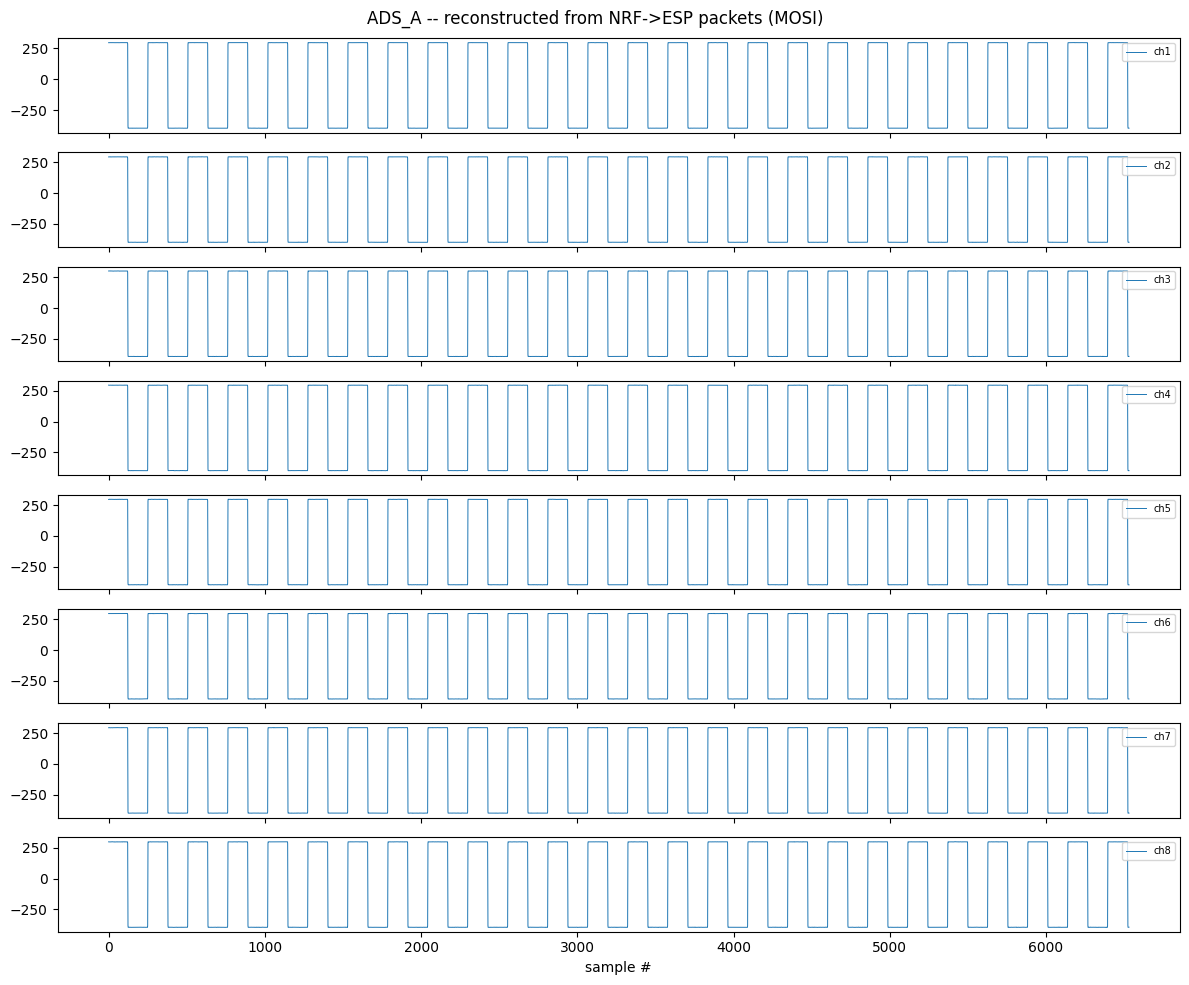

In [29]:
plot_block(esp_a, "ADS_A -- reconstructed from NRF->ESP packets (MOSI)")

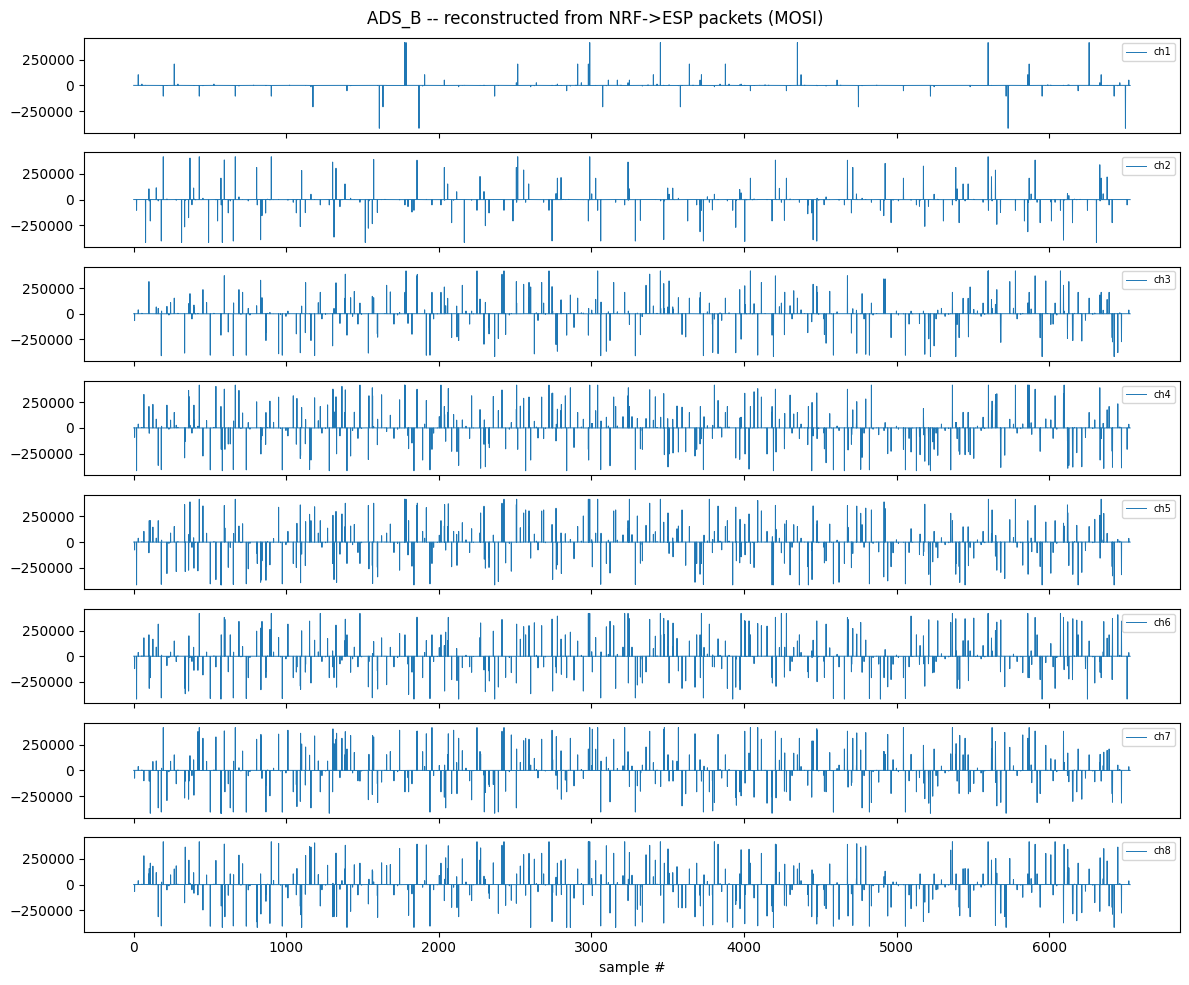

In [30]:
plot_block(esp_b, "ADS_B -- reconstructed from NRF->ESP packets (MOSI)")

## 6. How to read the result

| Observation | Conclusion |
|---|---|
| Direct-from-ADS-B is already garbage, and via-ESP matches it | Problem is at the ADS1298_B chip / its own SPI read (CS wiring, DOUT/MISO connection, power delivery to that specific chip) -- **not** the NRF<->ESP transport. |
| Direct-from-ADS-B is clean, but via-ESP is not | Problem is introduced during packet assembly (`ads_spi_data.c`) or on SPI_A during/after the hand-off -- worth revisiting the owner/mutex logic in `spi_a.c` and `wifi_sd_spi_functions.c`. |
| Both clean | No corruption in this capture window at all. |

First run of this notebook (2026-07-24 capture) landed in the first row: ADS_A clean throughout, ADS_B garbage identically in both the direct and via-ESP reconstructions -- pointing at ADS1298_B itself, not the transport.